<a href="https://colab.research.google.com/github/Rohit4507/llm-style-mimic/blob/main/llm_style_mimic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets sentence-transformers accelerate evaluate matplotlib seaborn tqdm peft bitsandbytes trl langchain langchain-community faiss-cpu

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer # Supervised Fine-Tuning Trainer

def setup_qlora_model(model_id="mistralai/Mistral-7B-v0.1"):
    # 1. Setup 4-bit quantization for memory efficiency
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )

    # 2. Load the modern model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto"
    )
    model = prepare_model_for_kbit_training(model)

    # 3. Apply LoRA Adapters (This acts as your "Style Adapter")
    lora_config = LoraConfig(
        r=16, # Rank
        lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"], # Target attention blocks
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    model = get_peft_model(model, lora_config)
    return model, tokenizer

# Usage within your existing loop:
# model, tokenizer = setup_qlora_model()
# Then pass this model to your Trainer (or SFTTrainer from the trl library)

In [3]:
!pip install -U datasets huggingface_hub

In [4]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news", split="train")

print("Total samples:", len(dataset))
print(dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total samples: 120000
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [5]:
authors = {}

for label in range(4):  # use 3 categories
    texts = [x["text"] for x in dataset if x["label"] == label]
    texts = [t for t in texts if 20 < len(t) <= 200]
    authors[f"author_{label}"] = texts[:300]

for k in authors:
    print(k, len(authors[k]))


author_0 300
author_1 300
author_2 300
author_3 300


In [7]:
import os
import torch
from google.colab import drive
from datasets import Dataset
from transformers import TrainingArguments
from trl import SFTTrainer
from peft import PeftModel

drive.mount('/content/drive')
BASE_SAVE_DIR = "/content/drive/MyDrive/micro_style_models"
os.makedirs(BASE_SAVE_DIR, exist_ok=True)

def fine_tune_or_load(texts, author_name,  base_model, tokenizer):
    save_path = os.path.join(BASE_SAVE_DIR, author_name)

    # 1. Initialize the modern base model and tokenizer
    print("Initializing base model and tokenizer for QLoRA...")
    base_peft_model, tokenizer = setup_qlora_model()

    # ✅ If model already exists → LOAD ADAPTER
    if os.path.exists(save_path):
        print(f"Loading saved LoRA adapter for {author_name}")
        # Extract the raw base model and attach the saved LoRA adapter to it
        model = PeftModel.from_pretrained("mistralai/Mistral-7B-v0.1", save_path)
        return model

    # ✅ Otherwise → TRAIN NEW ADAPTER
    print(f"Training new LoRA adapter for {author_name}")
    model = base_model

    # SFTTrainer natively accepts HuggingFace Datasets, so we convert the list of texts
    train_dataset = Dataset.from_dict({"text": texts})

    # Updated training arguments optimized for QLoRA and a 7B parameter model
    training_args = TrainingArguments(
        output_dir="./temp_training",
        per_device_train_batch_size=4, # Reduced to fit in Colab T4 GPU VRAM
        gradient_accumulation_steps=2, # Compensates for the smaller batch size
        num_train_epochs=2,
        save_strategy="no",
        logging_steps=10,
        learning_rate=2e-4, # Higher LR is standard for LoRA adapters
        fp16=True,
        optim="paged_adamw_8bit", # Keeps optimizer states in 8-bit to save memory
        report_to="none",
        max_grad_norm=0.3,
        warmup_ratio=0.03,
    )

    trainer = SFTTrainer(
        model=model,
        train_dataset=train_dataset,
        dataset_text_field="text", # Tells SFTTrainer which column contains the data
        max_seq_length=256,
        args=training_args,
        packing=False,
    )

    trainer.train()

    # ✅ SAVE ADAPTER TO DRIVE
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"LoRA Adapter saved for {author_name}")

    return model

Mounted at /content/drive


In [ ]:
DATA_SIZES = [25, 50, 100]
trained_models = {}
base_model, tokenizer = setup_qlora_model()

for author in authors:
    trained_models[author] = {}

    for size in DATA_SIZES:

        model_name = f"{author}_{size}"

        print(f"Processing {model_name}")

        trained_models[author][size] = fine_tune_or_load(
            authors[author][:size],
            model_name, base_model, tokenizer
        )


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [10]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate

class StyleRAGGenerator:
    def __init__(self, author_texts):
        # Initialize the same fast embedding model used for evaluation
        self.embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

        # Create a local vector database of the author's actual texts
        self.vectorstore = FAISS.from_texts(author_texts, self.embeddings)
        self.retriever = self.vectorstore.as_retriever(search_kwargs={"k": 3})

        self.prompt_template = PromptTemplate(
            input_variables=["exemplars", "topic"],
            template=(
                "You are an expert at emulating writing styles. Read the following examples of the author's work:\n"
                "{exemplars}\n\n"
                "Now, write a new paragraph about '{topic}' that perfectly mimics the cadence, vocabulary, "
                "and sentence structure of the examples above.\n"
                "Output:"
            )
        )

    def generate_anchored_text(self, model, tokenizer, topic="Technology and markets"):
        # 1. Retrieve stylistic exemplars related to the topic
        docs = self.retriever.invoke(topic)
        exemplars_text = "\n---\n".join([doc.page_content for doc in docs])

        # 2. Format the prompt
        final_prompt = self.prompt_template.format(exemplars=exemplars_text, topic=topic)

        # 3. Generate using the fine-tuned model
        inputs = tokenizer(final_prompt, return_tensors="pt").to("cuda")
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

        # 4. Slice the output to return only the newly generated text, not the prompt
        prompt_length = inputs["input_ids"].shape[1]
        return tokenizer.decode(outputs[0][prompt_length:], skip_special_tokens=True)

In [18]:
import json
from transformers import AutoTokenizer
from tqdm.auto import tqdm  # safe even if already imported


# Directory for saving generated texts
GEN_SAVE_DIR = "/content/drive/MyDrive/micro_style_generations"
os.makedirs(GEN_SAVE_DIR, exist_ok=True)

generated = {}

for author in authors:
    generated[author] = {}

    for size in DATA_SIZES:

        file_path = os.path.join(
            GEN_SAVE_DIR,
            f"{author}_{size}.json"
        )

        should_generate = True
        # ✅ If file exists → LOAD
        if os.path.exists(file_path):
            try:
                print(f"Loading generated texts for {author}_{size}")
                with open(file_path, "r") as f:
                    generated[author][size] = json.load(f)
                should_generate = False
            except json.JSONDecodeError:
                print(f"Corrupted or empty JSON file found for {author}_{size}. Regenerating.")

               # If file is corrupted, we proceed to generate

        # 1. Load the global tokenizer for generation
        print("Loading global tokenizer for generation...")
        tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")
        tokenizer.pad_token = tokenizer.eos_token

        # ✅ Otherwise or if corrupted → GENERATE with progress bar
        if should_generate:
            print(f"Generating texts for {author}_{size}")
            rag_generator = StyleRAGGenerator(authors[author])

            texts = [] # 2. Ensure this list is initialized!

            for _ in tqdm(
            range(20),
            desc=f"{author}_{size}",
            leave=False
        ):
                text = rag_generator.generate_anchored_text(trained_models[author][size], tokenizer, topic="Global finance and tech")
                texts.append(text)

            generated[author][size] = texts

            with open(file_path, "w") as f:
                json.dump(texts, f)

            print(f"Saved generations for {author}_{size}")

        print(f"Generated texts for {author}_{size}:")
        for i, text in enumerate(generated[author][size]):
            print(f"  {i+1}. {text}")
        print("\n")

Loading generated texts for author_0_25
Loading global tokenizer for generation...
Generated texts for author_0_25:
  1. 
Korea's first smartphone, the Galaxy S5, was released on Sept. 25. The phone is slated to hit the market on Oct. 15.

Korean handset manufacturer KOTG has launched the Korean smartphone in three-year
  2. Mariane's first saw the series on the show and was excited to see more of it. She's so excited to see how the show will fit with her life.

"I'm going to be very proud of the character of Marian
  3. Parks are to be closed and you can only buy them from the start of the year.

If you bought a pterosaur last year, you might want to ask your vet how many pterosaurs the family could have lived together
  4. 
"We are no longer the first city in the world that uses a non-traditional energy source," said Kari Ramesh, head of the New Delhi government, which has the largest solar energy program in India. "We were the only
  5. Thing to have been my entire life, though I'm 

In [19]:
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

def style_similarity(real, gen):
    real_emb = embedder.encode(real)
    gen_emb = embedder.encode(gen)
    sims = cosine_similarity(gen_emb, real_emb)
    return sims.mean()

In [21]:
import json
from tqdm.auto import tqdm

GEN_SAVE_DIR = "/content/drive/MyDrive/micro_style_generations"
os.makedirs(GEN_SAVE_DIR, exist_ok=True)

generated = {}

for author in authors:
    generated[author] = {}

    for size in DATA_SIZES:

        file_path = os.path.join(GEN_SAVE_DIR, f"{author}_{size}.json")

        should_generate = True

        if os.path.exists(file_path):
            try:
                print(f"Loading generated texts for {author}_{size}")
                with open(file_path, "r") as f:
                    generated[author][size] = json.load(f)
                should_generate = False
            except json.JSONDecodeError:
                print(f"Corrupted or empty JSON file found for {author}_{size}. Regenerating.")

        # ✅ MOVED inside if block — only runs when actually generating
        if should_generate:
            print(f"Generating texts for {author}_{size}")
            rag_generator = StyleRAGGenerator(authors[author])
            texts = []

            for _ in tqdm(range(20), desc=f"{author}_{size}", leave=False):
                text = rag_generator.generate_anchored_text(
                    trained_models[author][size], tokenizer,
                    topic="Global finance and tech"
                )
                texts.append(text)

            generated[author][size] = texts

            with open(file_path, "w") as f:
                json.dump(texts, f)

            print(f"Saved generations for {author}_{size}")

        print(f"Generated texts for {author}_{size}:")
        for i, text in enumerate(generated[author][size]):
            print(f"  {i+1}. {text}")
        print("\n")

Loading generated texts for author_0_25
Generated texts for author_0_25:
  1. 
Korea's first smartphone, the Galaxy S5, was released on Sept. 25. The phone is slated to hit the market on Oct. 15.

Korean handset manufacturer KOTG has launched the Korean smartphone in three-year
  2. Mariane's first saw the series on the show and was excited to see more of it. She's so excited to see how the show will fit with her life.

"I'm going to be very proud of the character of Marian
  3. Parks are to be closed and you can only buy them from the start of the year.

If you bought a pterosaur last year, you might want to ask your vet how many pterosaurs the family could have lived together
  4. 
"We are no longer the first city in the world that uses a non-traditional energy source," said Kari Ramesh, head of the New Delhi government, which has the largest solar energy program in India. "We were the only
  5. Thing to have been my entire life, though I'm glad that I finally got off the ground and 

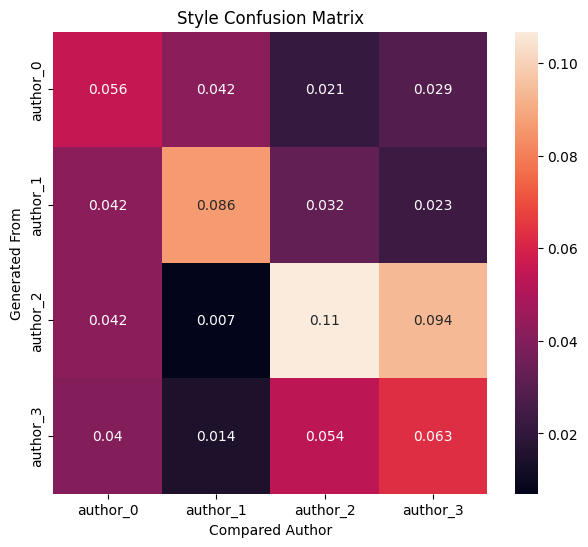

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

author_list = list(authors.keys())
n = len(author_list)

matrix = np.zeros((n, n))

for i, a in enumerate(author_list):
    gen = generated[a][100]
    for j, b in enumerate(author_list):
        matrix[i][j] = style_similarity(
            authors[b][150:250],
            gen
        )

plt.figure(figsize=(7,6))
sns.heatmap(matrix, annot=True,
            xticklabels=author_list,
            yticklabels=author_list)

plt.xlabel("Compared Author")
plt.ylabel("Generated From")
plt.title("Style Confusion Matrix")
plt.show()
